# HM1: Logistic Regression.

### Name: PALAK SOOD


#### For this assignment, you will build 6 models. You need to train Logistic Regression/Regularized Logistic Regression each with Batch Gradient Descent, Stochastic Gradient Descent, and Mini Batch Gradient Descent. Also you should plot their objective values versus epochs and compare their training and testing accuracies. You will need to tune the parameters a little bit to obtain reasonable results.

#### You do not have to follow the following procedure. You may implement your own functions and methods, but you need to show your results and plots.

In [251]:

import pandas as pd
from sklearn.model_selection import train_test_split
import sklearn

# 1. Data processing

- Download the data. Please see HW PDF for more detail. 
- Load the data.
- Preprocess the data.

## 1.1. Load the data

In [252]:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
df = pd.read_csv(url, header=None)
print(df.head())
print(df.info())
print(df.describe())


         0  1      2      3       4       5        6        7       8   \
0    842302  M  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.3001   
1    842517  M  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.0869   
2  84300903  M  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.1974   
3  84348301  M  11.42  20.38   77.58   386.1  0.14250  0.28390  0.2414   
4  84358402  M  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.1980   

        9   ...     22     23      24      25      26      27      28      29  \
0  0.14710  ...  25.38  17.33  184.60  2019.0  0.1622  0.6656  0.7119  0.2654   
1  0.07017  ...  24.99  23.41  158.80  1956.0  0.1238  0.1866  0.2416  0.1860   
2  0.12790  ...  23.57  25.53  152.50  1709.0  0.1444  0.4245  0.4504  0.2430   
3  0.10520  ...  14.91  26.50   98.87   567.7  0.2098  0.8663  0.6869  0.2575   
4  0.10430  ...  22.54  16.67  152.20  1575.0  0.1374  0.2050  0.4000  0.1625   

       30       31  
0  0.4601  0.11890  
1  0.2750  0.08902  
2  0.

In [253]:
columns = [
    "id","diagnosis","radius_mean", "texture_mean", "perimeter_mean", "area_mean", 
    "smoothness_mean","compactness_mean", "concavity_mean", "concave_points_mean", 
    "symmetry_mean","fractal_dimension_mean","radius_se", "texture_se", "perimeter_se", 
    "area_se", "smoothness_se","compactness_se", "concavity_se", "concave_points_se", 
    "symmetry_se","fractal_dimension_se","radius_worst", "texture_worst", "perimeter_worst", 
    "area_worst","smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df.columns = columns
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [254]:
# checking Missing values and duplicates
print(df.isnull().sum())
print("Unique IDs:", df["id"].nunique(), "Total rows:", len(df))


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64
Unique IDs: 569 Total rows: 569


## 1.2 Examine and clean data

In [ ]:

# Some columns may not be useful for the model (For example, the first column contains ID number which may be irrelavant). 
# You need to get rid of the ID number feature.
# Also you should transform target labels in the second column from 'B' and 'M' to 1 and -1.
df["diagnosis"] = df["diagnosis"].map({"M": -1, "B": 1})
df = df.drop(columns=["id"])

print(df["diagnosis"].value_counts())
print(df["diagnosis"].value_counts(normalize=True))
df


diagnosis
 1    357
-1    212
Name: count, dtype: int64
diagnosis
 1    0.627417
-1    0.372583
Name: proportion, dtype: float64


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,-1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,-1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,-1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,-1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,-1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,-1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,-1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,-1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,-1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


## 1.3. Partition training and testing

In [256]:
# You can partition using 80% training data and 20% testing data. It is a commonly used ratio in machine learning.
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:, 1:31], df.diagnosis, test_size=0.2, random_state=0)


## 1.4. Feature scaling

Use the standardization to transform both training and test features.

In [257]:
# Standardization
import numpy

# calculate mu and sig using the training set
d = x_train.shape[1]
mu = numpy.mean(x_train, axis=0).values.reshape(1, d)
sig = numpy.std(x_train, axis=0).values.reshape(1, d)

# transform the training features
x_train = (x_train - mu) / (sig + 1E-6)

# transform the test features
x_test = (x_test - mu) / (sig + 1E-6)

print('test mean = ')
print(numpy.mean(x_test, axis=0))

print('test std = ')
print(numpy.std(x_test, axis=0))


test mean = 
radius_mean                0.020907
texture_mean               0.164319
perimeter_mean             0.030981
area_mean                  0.014927
smoothness_mean           -0.019211
compactness_mean           0.101172
concavity_mean             0.084439
concave_points_mean        0.029660
symmetry_mean              0.040621
fractal_dimension_mean     0.094946
radius_se                  0.046538
texture_se                 0.064287
perimeter_se               0.100075
area_se                    0.005387
smoothness_se              0.066020
compactness_se             0.118395
concavity_se               0.067615
concave_points_se          0.126894
symmetry_se                0.010380
fractal_dimension_se       0.161937
radius_worst               0.013377
texture_worst              0.113419
perimeter_worst            0.033903
area_worst                -0.005170
smoothness_worst          -0.020016
compactness_worst          0.078428
concavity_worst            0.117564
concave_points_

In [258]:
# Adding bias
import numpy as np
train, _ = x_train.shape
x_train = np.concatenate((x_train, np.ones((train, 1))), axis=1)
test, _ = x_test.shape
x_test = np.concatenate((x_test, np.ones((test, 1))), axis=1)

# 2.  Logistic Regression Model

The objective function is $Q (w; X, y) = \frac{1}{n} \sum_{i=1}^n \log \Big( 1 + \exp \big( - y_i x_i^T w \big) \Big) + \frac{\lambda}{2} \| w \|_2^2 $.

When $\lambda = 0$, the model is a regular logistic regression and when $\lambda > 0$, it essentially becomes a regularized logistic regression.

In [259]:
# Calculate the objective function value, or loss
# Inputs:
#     w: weight: d-by-1 vector
#     x: data: n-by-d matrix
#     y: label: n-by-1 vector
#     lam: regularization parameter: scalar
# Return:
#     objective function value, or loss (scalar)
def objective(w, x, y, lam):
    linear_term = -y * (x@w)
    log_loss = np.log(1 + np.exp(linear_term))
    Q = np.mean(log_loss) + (lam/2) * np.sum(np.square(w[:-1]))
    return Q

# 3. Numerical optimization

## 3.1. Gradient descent


The gradient at $w$ for regularized logistic regression is  $g = - \frac{1}{n} \sum_{i=1}^n \frac{y_i x_i }{1 + \exp ( y_i x_i^T w)} + \lambda w$

In [260]:
#check# Calculate the gradient
# Inputs:
#     w: weight: d-by-1 vector
#     x: data: n-by-d matrix
#     y: label: n-by-1 vector
#     lam: regularization parameter: scalar
# Return:
#     g: gradient: d-by-1 matrix

def gradient(w, x, y, lam):
    yx = np.multiply(y, x)
    logits = np.dot(yx, w)
    g = -np.mean(np.divide(yx, (1 + np.exp(np.clip(logits, -500, 500)))), axis=0).reshape(x.shape[1], 1)
    reg = lam * w.copy()
    reg[-1] = 0.0        # exclude bias from regularization
    g = g + reg
    return g

In [261]:
# Gradient descent for solving logistic regression
# You will need to do iterative process (loops) to obtain optimal weights in this function

# Inputs:
#     x: data: n-by-d matrix
#     y: label: n-by-1 vector
#     lam: scalar, the regularization parameter
#     learning_rate: scalar
#     w: weights: d-by-1 vector, initialization of w
#     max_epoch: integer, the maximal epochs
# Return:
#     w: weights: d-by-1 vector, the solution
#     objvals: a record of each epoch's objective value

def gradient_descent(x, y, lam, learning_rate, w, max_epoch=100):
    objvals = np.zeros(max_epoch)
    w = np.zeros((x.shape[1], 1))
    y = np.array(y).reshape(x.shape[0],1)
        
    for i in range(max_epoch):
        g = gradient(w, x, y, lam)
        w -= learning_rate * g
        objval = objective(w, x, y, lam)
        objvals[i] = objval
    return w, objvals

Use gradient_descent function to obtain your optimal weights and a list of objective values over each epoch.

In [262]:
# Train logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.
w, objvals = gradient_descent(x_train, y_train, 0, 0.01,1000)

In [263]:
# Train regularized logistric regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.
lam = 1E-6
w_reg, objvals_reg = gradient_descent(x_train, y_train, lam, 0.01, 1000)

## 3.2. Stochastic gradient descent (SGD)

Define new objective function $Q_i (w) = \log \Big( 1 + \exp \big( - y_i x_i^T w \big) \Big) + \frac{\lambda}{2} \| w \|_2^2 $. 

The stochastic gradient at $w$ is $g_i = \frac{\partial Q_i }{ \partial w} = -\frac{y_i x_i }{1 + \exp ( y_i x_i^T w)} + \lambda w$.

You may need to implement a new function to calculate the new objective function and gradients.

In [264]:
# Calculate the objective Q_i and the gradient of Q_i
# Inputs:
#     w: weights: d-by-1 vector
#     xi: data: 1-by-d vector
#     yi: label: scalar
#     lam: scalar, the regularization parameter
# Return:
#     obj: scalar, the objective Q_i
#     g: d-by-1 vector, gradient of Q_i

def stochastic_objective_gradient(w, xi, yi, lam):
    yx = np.multiply(yi,xi)
    yxw = np.dot(yx,w).item()
    log_loss = np.log(1+ np.exp(np.clip(-yxw,-500,500)))
    reg_term = (lam/2) * np.sum(np.square(w[:-1]))
    obj = float(log_loss) + reg_term
    log_grad = -(np.multiply(yi, xi)) / (1 + np.exp(np.clip(yxw, -500, 500)))  # fix: clip here too
    reg_grad = lam * w.copy()
    reg_grad[-1] = 0.0                  # fix: exclude bias; drop the reshape
    g = log_grad.reshape(w.shape) + reg_grad  # fix: reshape log_grad to match w shape (d,1)
    return obj, g

Hints:
1. In every epoch, randomly permute the $n$ samples.
2. Each epoch has $n$ iterations. In every iteration, use 1 sample, and compute the gradient and objective using the ``stochastic_objective_gradient`` function. In the next iteration, use the next sample, and so on.

In [265]:
# SGD for solving logistic regression
# You will need to do iterative process (loops) to obtain optimal weights in this function

# Inputs:
#     x: data: n-by-d matrix
#     y: label: n-by-1 vector
#     lam: scalar, the regularization parameter
#     learning_rate: scalar
#     w: weights: d-by-1 vector, initialization of w
#     max_epoch: integer, the maximal epochs
# Return:
#     
#     w: weights: d-by-1 vector, the solution
#     objvals: a record of each epoch's objective value
#     Record one objective value per epoch (not per iteration)

def sgd(x, y, lam, learning_rate, w, max_epoch=100):
    objvals = [0] * max_epoch
    w = np.zeros((x.shape[1],1)) 
    y = np.array(y).reshape((x.shape[0], 1))
    
    for i in range(max_epoch):
        random_samples = np.random.permutation(x.shape[0])
        x_samples = x[random_samples,:]
        y_samples = y[random_samples,:]
    
        objval = 0
        
        for j in range(x.shape[0]):
            xi = x_samples[j,:]
            yi = y_samples[j,0]
            obj, g = stochastic_objective_gradient(w, xi, yi, lam)
            objval += obj
            w-= learning_rate * g  
        objval /= x.shape[0]
        objvals[i] = objval
    return w, objvals

Use sgd function to obtain your optimal weights and a list of objective values over each epoch.

In [266]:
# Train logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.
w_sgd, objvals_sgd = sgd(x_train, y_train, 0, 0.01, 1000)

In [267]:
# Train regularized logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.
w_sgd_reg, objvals_sgd_reg = sgd(x_train, y_train, lam, 0.01, 1000)

## 3.3 Mini-Batch Gradient Descent (MBGD)

Define $Q_I (w) = \frac{1}{b} \sum_{i \in I} \log \Big( 1 + \exp \big( - y_i x_i^T w \big) \Big) + \frac{\lambda}{2} \| w \|_2^2 $, where $I$ is a set containing $b$ indices randomly drawn from $\{ 1, \cdots , n \}$ without replacement.

The stochastic gradient at $w$ is $g_I = \frac{\partial Q_I }{ \partial w} = \frac{1}{b} \sum_{i \in I} \frac{- y_i x_i }{1 + \exp ( y_i x_i^T w)} + \lambda w$.

You may need to implement a new function to calculate the new objective function and gradients.

In [268]:
# Calculate the objective Q_I and the gradient of Q_I
# Inputs:
#     w: weights: d-by-1 vector
#     xi: data: b-by-d matrix
#     yi: label: scalar
#     lam: scalar, the regularization parameter
# Return:
#     obj: scalar, the objective Q_i
#     g: d-by-1 vector, gradient of Q_i

def mb_objective_gradient(w, xi, yi, lam):
    yx = np.multiply(yi,xi)
    yxw = np.dot(yx,w)
    obj = np.mean(np.log(1 + np.exp(np.clip(-yxw, -500, 500)))) + (lam / 2) * np.sum(np.square(w))
    g = np.mean(np.divide(-yx , (1 + np.exp(yxw))),axis = 0).reshape(xi.shape[1],1) + lam * w.copy()

    return obj, g

Hints:
1. In every epoch, randomly permute the $n$ samples (just like SGD).
2. Each epoch has $\frac{n}{b}$ iterations. In every iteration, use $b$ samples, and compute the gradient and objective using the ``mb_objective_gradient`` function. In the next iteration, use the next $b$ samples, and so on.

In [269]:
# MBGD for solving logistic regression
# You will need to do iterative process (loops) to obtain optimal weights in this function

# Inputs:
#     x: data: n-by-d matrix
#     y: label: n-by-1 vector
#     lam: scalar, the regularization parameter
#     learning_rate: scalar
#     w: weights: d-by-1 vector, initialization of w
#     max_epoch: integer, the maximal epochs
# Return:
#     w: weights: d-by-1 vector, the solution
#     objvals: a record of each epoch's objective value
#     Record one objective value per epoch (not per iteration)

def mbgd(x, y, lam, learning_rate, w, max_epoch=100):
    objvals = [0] * max_epoch
    b = 20
    w = np.zeros((x.shape[1], 1))
    y = np.array(y).reshape((x.shape[0], 1))
    for i in range(max_epoch):
        random_samples = np.random.permutation(x.shape[0])
        x_samples = x[random_samples,: ]
        y_samples = y[random_samples,:]
    
        objval = 0
        n_batches = 0
        for k in range(x.shape[0] // b):
            xBatch = x_samples[k * b: k * b + b]
            yBatch = y_samples[k * b: k * b + b]
            obj, g = mb_objective_gradient(w, xBatch, yBatch, lam)
            objval += obj
            n_batches += 1
            temp = np.multiply(learning_rate, g)
            w -= temp
        
        objval /= n_batches 
        objvals[i] = objval
    
    return w, objvals

Use mbgd function to obtain your optimal weights and a list of objective values over each epoch.

In [270]:
# Train logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.
w_mbgd, objvals_mbgd = mbgd(x_train, y_train, 0, 0.01, 50, 1000)

In [271]:
# Train regularized logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.
w_mbgd_reg, objvals_mbgd_reg = mbgd(x_train, y_train, 1E-6, 0.01, 50, 1000)

# 4. Compare GD, SGD, MBGD

### Plot objective function values against epochs.

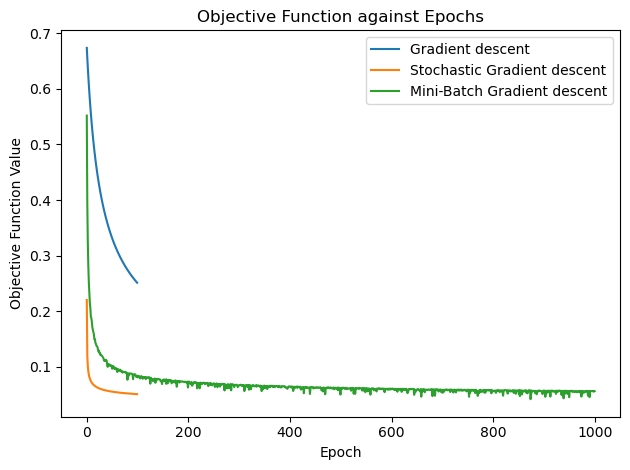

In [272]:
import matplotlib.pyplot as plt
%matplotlib inline
gd_epochs = range(len(objvals))
sgd_epochs = range(len(objvals_sgd))
mbgd_epochs = range(len(objvals_mbgd))

l1, = plt.plot(gd_epochs, objvals)
l2, = plt.plot(sgd_epochs, objvals_sgd)
l3, = plt.plot(mbgd_epochs, objvals_mbgd)
plt.title("Objective Function against Epochs")
plt.xlabel('Epoch')
plt.ylabel('Objective Function Value')
plt.legend([l1, l2, l3], ['Gradient descent', 'Stochastic Gradient descent', 'Mini-Batch Gradient descent'])
plt.tight_layout()

plt.show()




# 5. Prediction
### Compare the training and testing accuracy for logistic regression and regularized logistic regression.

In [273]:
# Predict class label
# Inputs:
#     w: weights: d-by-1 vector
#     X: data: m-by-d matrix
# Return:
#     f: m-by-1 vector, the predictions
def predict(w, X):
    x_w = np.dot(X,w)
    f = np.array([1 if i > 0 else -1 for i in x_w])
    return f

In [274]:
# evaluate training error of logistic regression and regularized version

gd_prediction = predict(w, x_train)
gd_error = np.mean(gd_prediction != np.array(y_train).ravel())
print("Training error Accuracy for GD: " + str(1 - gd_error))

# Regularized Gradient descent
reg_gd_predict = predict(w_reg, x_train)
reg_gd_error = np.mean(reg_gd_predict != np.array(y_train).ravel())
print("Training error Accuracy for Regularized GD: " + str(1 - reg_gd_error))

# Stochastic Gradient Descent
sgd_predict = predict(w_sgd, x_train)
sgd_error = np.mean(sgd_predict != np.array(y_train).ravel())
print("Training error Accuracy for SGD: " + str(1 - sgd_error))

# Regularized Stochastic Gradient Descent
reg_sgd_predict = predict(w_sgd_reg, x_train)
reg_sgd_error = np.mean(reg_sgd_predict != np.array(y_train).ravel())
print("Training error Accuracy for Regularized SGD: " + str(1 - reg_sgd_error))

# Mini-Batch Gradient Descent
mbgd_predict = predict(w_mbgd, x_train)
mbgd_error = np.mean(mbgd_predict != np.array(y_train).ravel())
print("Training error Accuracy for MBGD: " + str(1 - mbgd_error))

# Regularized Mini-Batch Gradient Descent
reg_mbgd_predict = predict(w_mbgd_reg, x_train)
reg_mgbd_error = np.mean(reg_mbgd_predict != np.array(y_train).ravel())
print("Training error Accuracy for Regularized MBGD: " + str(1 - reg_mgbd_error))

Training error Accuracy for GD: 0.9626373626373627
Training error Accuracy for Regularized GD: 0.9626373626373627
Training error Accuracy for SGD: 0.9912087912087912
Training error Accuracy for Regularized SGD: 0.9912087912087912
Training error Accuracy for MBGD: 0.989010989010989
Training error Accuracy for Regularized MBGD: 0.989010989010989


In [275]:
# evaluate testing error of logistic regression and regularized version
gd_prediction = predict(w, x_test)
gd_error = np.mean(np.abs(gd_prediction - np.array(y_test).ravel()) / 2)
print("Testing error Accuracy for GD: " + str(1 - gd_error))

# Regularized Gradient descent
reg_gd_predict = predict(w_reg, x_test)
reg_gd_error = np.mean(np.abs(reg_gd_predict - np.array(y_test).ravel()) / 2)
print("Testing error Accuracy for Regularized GD: " + str(1 - reg_gd_error))

# Stochastic Gradient Descent
sgd_predict = predict(w_sgd, x_test)
sgd_error = np.mean(np.abs(sgd_predict - np.array(y_test).ravel()) / 2)
print("Testing error Accuracy for SGD: " + str(1 - sgd_error))

# Regularized Stochastic Gradient Descent
reg_sgd_predict = predict(w_sgd_reg, x_test)
reg_sgd_error = np.mean(np.abs(reg_sgd_predict - np.array(y_test).ravel()) / 2)
print("Testing error Accuracy for Regularized SGD: " + str(1 - reg_sgd_error))

# Mini-Batch Gradient Descent
mbgd_predict = predict(w_mbgd, x_test)
mbgd_error = np.mean(np.abs(mbgd_predict - np.array(y_test).ravel()) / 2)
print("Testing error Accuracy for MBGD: " + str(1 - mbgd_error))

# Regularized Mini-Batch Gradient Descent
reg_mbgd_predict = predict(w_mbgd_reg, x_test)
reg_mgbd_error = np.mean(np.abs(reg_mbgd_predict - np.array(y_test).ravel()) / 2)
print("Testing error Accuracy for Regularized MBGD: " + str(1 - reg_mgbd_error))

Testing error Accuracy for GD: 0.9210526315789473
Testing error Accuracy for Regularized GD: 0.9210526315789473
Testing error Accuracy for SGD: 0.9649122807017544
Testing error Accuracy for Regularized SGD: 0.9649122807017544
Testing error Accuracy for MBGD: 0.9649122807017544
Testing error Accuracy for Regularized MBGD: 0.9649122807017544


# 6. Parameters tuning

### In this section, you may try different combinations of parameters (regularization value, learning rate, etc) to see their effects on the model. (Open-ended question)

In [276]:
learning_rates = [0.005, 0.02, 0.05]
lambdas = [0.001, 0.05, 0.1, 0.2]
batch_sizes = [32, 64, 128]
max_epochs = 800 

results = {model: [] for model in ["GD", "GD_Reg", "SGD", "SGD_Reg", "MBGD", "MBGD_Reg"]}

for alpha in learning_rates:
    for lam in lambdas:
        # Batch Gradient Descent (GD)
        for method, func in [("GD", gradient_descent), ("GD_Reg", gradient_descent)]:
            if method == "GD" and lam > 0.0:
                continue
            w, _ = func(x_train, y_train, lam, alpha, max_epochs)
            train_acc = 1 - np.mean(np.abs(predict(w, x_train) - y_train) / 2)
            test_acc = 1 - np.mean(np.abs(predict(w, x_test) - y_test) / 2)
            results[method].append((alpha, lam, train_acc, test_acc))

        # Stochastic Gradient Descent (SGD)
        for method, func in [("SGD", sgd), ("SGD_Reg", sgd)]:
            if method == "SGD" and lam > 0.0:
                continue
            w, _ = func(x_train, y_train, lam, alpha, max_epochs)
            train_acc = 1 - np.mean(np.abs(predict(w, x_train) - y_train) / 2)
            test_acc = 1 - np.mean(np.abs(predict(w, x_test) - y_test) / 2)
            results[method].append((alpha, lam, train_acc, test_acc))

        # Mini-Batch Gradient Descent (MBGD)
        for batch_size in batch_sizes:
            for method, func in [("MBGD", mbgd), ("MBGD_Reg", mbgd)]:
                if method == "MBGD" and lam > 0.0:
                    continue
                w, _ = func(x_train, y_train, lam, alpha, batch_size, max_epochs)
                train_acc = 1 - np.mean(np.abs(predict(w, x_train) - y_train) / 2)
                test_acc = 1 - np.mean(np.abs(predict(w, x_test) - y_test) / 2)
                results[method].append((alpha, lam, batch_size, train_acc, test_acc))


In [277]:
# Display results
for model, outcomes in results.items():
    print(f"\n{model} Results:")
    for res in outcomes:
        if "MBGD" in model:
            print(f"alpha={res[0]}, lambda={res[1]}, batch_size={res[2]}, Training Accuracy={res[3]:.4f}, Testing Accuracy={res[4]:.4f}")
        else:
            print(f"alpha={res[0]}, lambda={res[1]}, Training Accuracy={res[2]:.4f}, Testing Accuracy={res[3]:.4f}")


GD Results:

GD_Reg Results:
alpha=0.005, lambda=0.001, Training Accuracy=0.9538, Testing Accuracy=0.9123
alpha=0.005, lambda=0.05, Training Accuracy=0.9538, Testing Accuracy=0.9123
alpha=0.005, lambda=0.1, Training Accuracy=0.9538, Testing Accuracy=0.9123
alpha=0.005, lambda=0.2, Training Accuracy=0.9538, Testing Accuracy=0.9123
alpha=0.02, lambda=0.001, Training Accuracy=0.9714, Testing Accuracy=0.9386
alpha=0.02, lambda=0.05, Training Accuracy=0.9714, Testing Accuracy=0.9386
alpha=0.02, lambda=0.1, Training Accuracy=0.9714, Testing Accuracy=0.9386
alpha=0.02, lambda=0.2, Training Accuracy=0.9714, Testing Accuracy=0.9386
alpha=0.05, lambda=0.001, Training Accuracy=0.9736, Testing Accuracy=0.9561
alpha=0.05, lambda=0.05, Training Accuracy=0.9736, Testing Accuracy=0.9561
alpha=0.05, lambda=0.1, Training Accuracy=0.9736, Testing Accuracy=0.9474
alpha=0.05, lambda=0.2, Training Accuracy=0.9714, Testing Accuracy=0.9386

SGD Results:

SGD_Reg Results:
alpha=0.005, lambda=0.001, Training A